# Applying Deep Learning to TCR Data

## Learning Objectives

By the end of this notebook, you will:

* Learn how deep learning is applied to TCR analysis
* Become familiar with common machine learning libraries used in bioinformatics
* Train and test a simple deep learning model on TCR data
* Interpret model predictions and evaluate performance

---

# Exploring the TCR Dataset

## Introduction

T-cell receptor (TCR) sequencing data is commonly used to study immune responses, antigen specificity, autoimmune diseases, and cancer immunology.

In this tutorial, we will be **utilizing deep learning to detect cancer samples using TCR sequences**

### What Does TCR Data Look Like?

Typical TCR datasets may contain:

* TCR amino acid sequences
* V(D)J gene usage
* Clonotype frequencies
* Patient/sample metadata
* Disease or antigen labels

For this workshop we will only be looking at and utilising the **amino acid sequences**

### Data Splits

Machine learning workflows commonly divide data into:

* Training set
* Validation set
* Test set (external)

This helps evaluate how well a model generalises to unseen data.
For this workshop, we will only be using training and testing sets

---

Modern bioinformatics workflows often combine machine learning and deep learning techniques for analysing biological sequence data.

## Libraries Covered
<img src="https://upload.wikimedia.org/wikipedia/commons/9/96/Pytorch_logo.png" width="300">

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/05/Scikit_learn_logo_small.svg/3840px-Scikit_learn_logo_small.svg.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail" width="300">

### PyTorch

PyTorch is a deep learning framework commonly used for:

* Building neural networks
* GPU acceleration
* Automatic differentiation
* Training deep learning models

### scikit-learn

scikit-learn provides:

* Classical machine learning algorithms
* Dataset splitting utilities
* Evaluation metrics
* Preprocessing tools

in this example, we will mostly be using sklearn's evaluation functions (ROC, F1 score)

## Key Deep Learning Concepts

### Tensors

Tensors are multidimensional arrays used as the primary data structure in deep learning frameworks.

### Neural Networks

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/46/Colored_neural_network.svg/1280px-Colored_neural_network.svg.png" width="400">


Deep learning models consist of layers that learn patterns from input data.

For TCR analysis, models may learn:

* Sequence motifs
* Antigen-associated patterns
* Disease-specific signatures

---

#### Again, lets first install and import all the packages necessary to run this notebook

In [8]:
# clone the repository so that we have all the data and notebooks ready to go
!git clone https://github.com/tuonglab/FIMSA-training-workshop-1.git

fatal: destination path 'FIMSA-training-workshop-1' already exists and is not an empty directory.


In [9]:
# initialise any imports
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

### 🗣️ Think, pair, share 🏋️ Exercise!

What biological and sequence-level features of a T-cell receptor (TCR) might a deep learning model learn to recognise?

In [ ]:
# Discuss and enter your answers here


#### Lets load our TCR data, we will be utilizing amino acid sequences of cancerous and healthy TCR data

In [25]:
# load cancer and control sequences as lists, manipulate data in lists, and then output a numpy array

cancer_training_path = (
    "/content/FIMSA-training-workshop-1/data/tutorial_3/cancer_training_data.txt"
)
control_training_path = (
    "/content/FIMSA-training-workshop-1/data/tutorial_3/control_training_data.txt"
)

cancer_training_seqs = [
    line.strip() for line in open(cancer_training_path) if line.strip()
]
control_training_seqs = [
    line.strip() for line in open(control_training_path) if line.strip()
]

print(
    f"Training set contains {len(cancer_training_seqs)} cancer sequences and {len(control_training_seqs)} healthy sequences"
)
print(f"\nExample cancer sequence: {cancer_training_seqs[0]}")

Training set contains 5000 cancer sequences and 5000 healthy sequences

Example cancer sequence: @@@@@@CSARGPTSTDTQYF@@@@@@@


#### Since deep learning models can't explicitly understand text characters such as 'C' or 'D', lets convert them into a **numerical representation** that can be understood by the model

In [11]:
# load AA indices as a dictionary
aa_index_path = "/content/FIMSA-training-workshop-1/data/tutorial_3/AAidx_PCA_2024.txt"
with open(aa_index_path) as f:
    next(f)  # skip header
    aaidx_dict = {
        p[0]: list(map(float, p[1:])) for line in f if (p := line.strip().split("\t"))
    }

num_features = len(aaidx_dict["C"])
print(
    f"the numerical vector for 'C' is {aaidx_dict['C']} and has length {num_features}"
)

the numerical vector for 'C' is [8.263782073274541, 8.355436763283517, -5.918452287478518, -14.414201802910007, 12.698390941968125, -6.393774682844861, -3.5241563819552266, -4.560058137275353, -2.210810896179773, 4.122489674532446, 2.4152894167203987, 0.5756545997162357, 1.1078165871072982, -0.31685467491914343] and has length 14


In [12]:
# convert features
def aaindex_encoding(sequence, num_features, aaidx_dict):
    sequence_length = len(sequence)
    encoded_sequence = np.zeros((sequence_length, num_features), dtype=np.float32)

    # converts each amino acid in the sequence to its corresponding feature vector
    for position in range(sequence_length):
        current_aa = sequence[position]
        try:
            encoded_sequence[position, :] = aaidx_dict[current_aa]
        except KeyError:
            pass

    return encoded_sequence

In [13]:
training_data = []
training_labels = []

# convert sequences to features and labels
for seq in cancer_training_seqs:
    training_data.append(aaindex_encoding(seq, num_features, aaidx_dict))
    training_labels.append(1)

for seq in control_training_seqs:
    training_data.append(aaindex_encoding(seq, num_features, aaidx_dict))
    training_labels.append(0)

print(f"total training set contains {len(training_data)} sequences")

total training set contains 10000 sequences


# Training a Small Deep Learning Model

## Introduction

Training deep learning models can take significant computational time.

For this seminar, we will train a small model on a subset of the data using only a few epochs to demonstrate the workflow while keeping runtime manageable.

## Topics Covered

* Creating a simple neural network
* Preparing data for training
* Training on a small TCR dataset
* Monitoring loss during training
* Understanding optimisation steps

<img src="https://miro.medium.com/1*ZXAOUqmlyECgfVa81Sr6Ew.png" width=1000/>

## Training Workflow

### Step 1 — Forward Pass

The model receives input sequences and generates predictions.

### Step 2 — Loss Calculation

The loss function measures how different the predictions are from the true labels.

### Step 3 — Backpropagation

The model updates its parameters based on prediction errors.

### Step 4 — Optimisation

The optimiser adjusts model weights to improve performance.

## Epochs

An epoch represents one complete pass through the training dataset.

## Monitoring Training

During training, we commonly track:

* Training loss
* Validation loss (If there is a validation set)
* Accuracy

Visualising these metrics helps identify:

* Model improvement
* Overfitting
* Training instability

## Computational Considerations

Deep learning models may require:

* GPUs
* Large memory resources
* Longer training times

Training large TCR models on full datasets may take hours or days depending on model complexity.

---

#### Firstly we need to convert our current input to a "Tensor", which is a datatype that deep learning models use to process data

<img src="https://cdn.discuss.boardinfinity.com/original/2X/c/ce5332e512a39e0814b2f94ee91361f76cd0b065.png" width=1000/>

In [14]:
# Converting input to type 'Tensor', a data type that deep learning models use to process data
X = np.array(training_data, dtype=np.float32)
y = np.array(training_labels, dtype=np.int64)

X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y)

"""
CNNs expect:
 (batch, channels, height, width)

our current shape is:
 (N, seq_len, features)

our shape will get converted to:
 (N, 1, features, seq_len)
"""

X_tensor = X_tensor.permute(0, 2, 1).unsqueeze(1)

print(f"Shape of the input tensor: {X_tensor.shape}")

Shape of the input tensor: torch.Size([10000, 1, 14, 27])


#### Next, we need to define the architecture of our model, for this workshop we will use a simple Convolutional Neural Network with just a few layers

<img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2024/08/183560-qcmbdpukpdviccdd-66c7065d8f850.webp" width=1400/>

In [15]:
# DEFINING OUR DEEP LEARNING MODEL
class SimpleTCRCNN(nn.Module):
    """
    Simple Convolutional Neural Network for classifying AAindex-encoded TCR sequences
    (e.g., cancer vs control).

    The model applies a 2D convolution over sequence features to
    capture local amino acid motifs, followed by a linear classifier.

    Parameters
    ----------
    num_features : int
        Number of AAindex features per residue.

    Input
    -----
    Tensor of shape (batch_size, 1, num_features, sequence_length)

    Output
    ------
    Tensor of shape (batch_size, 2)
        Class logits (e.g., cancer vs control).
    """

    def __init__(self, num_features):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=1, out_channels=8, kernel_size=(num_features, 3)
        )
        self.relu = nn.ReLU()
        self.fc = nn.Linear(8 * 25, 2)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

#### After that we need to initialize our model as well as define our loss function and optimizer

In [16]:
# INITIALIZE MODEL
model = SimpleTCRCNN(num_features)

# LOSS
criterion = nn.CrossEntropyLoss()

# OPTIMIZER
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#### After everything has been defined, we can finally begin training

In [17]:
# lists for storing and keeping track of losses and accuracies
train_losses = []
train_accuracies = []

# number of epochs/iterations to train for
num_epochs = 1000

# TRAINING LOOP
for epoch in range(num_epochs):

    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    preds = torch.argmax(outputs, dim=1)
    accuracy = (preds == y_tensor).float().mean()

    # save metrics
    train_losses.append(loss.item())
    train_accuracies.append(accuracy.item())

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {loss.item():.4f} | "
        f"Accuracy: {accuracy.item():.4f}"
    )
print("Training complete!")

Epoch 1 | Loss: 0.9645 | Accuracy: 0.4808
Epoch 2 | Loss: 0.9026 | Accuracy: 0.4868
Epoch 3 | Loss: 0.8625 | Accuracy: 0.4978
Epoch 4 | Loss: 0.8370 | Accuracy: 0.5095
Epoch 5 | Loss: 0.8191 | Accuracy: 0.5173
Epoch 6 | Loss: 0.8036 | Accuracy: 0.5277
Epoch 7 | Loss: 0.7881 | Accuracy: 0.5320
Epoch 8 | Loss: 0.7720 | Accuracy: 0.5409
Epoch 9 | Loss: 0.7564 | Accuracy: 0.5496
Epoch 10 | Loss: 0.7423 | Accuracy: 0.5592
Epoch 11 | Loss: 0.7308 | Accuracy: 0.5708
Epoch 12 | Loss: 0.7222 | Accuracy: 0.5766
Epoch 13 | Loss: 0.7161 | Accuracy: 0.5836
Epoch 14 | Loss: 0.7114 | Accuracy: 0.5913
Epoch 15 | Loss: 0.7072 | Accuracy: 0.5958
Epoch 16 | Loss: 0.7028 | Accuracy: 0.5975
Epoch 17 | Loss: 0.6979 | Accuracy: 0.6003
Epoch 18 | Loss: 0.6926 | Accuracy: 0.6026
Epoch 19 | Loss: 0.6875 | Accuracy: 0.6050
Epoch 20 | Loss: 0.6827 | Accuracy: 0.6084
Epoch 21 | Loss: 0.6787 | Accuracy: 0.6147
Epoch 22 | Loss: 0.6753 | Accuracy: 0.6170
Epoch 23 | Loss: 0.6725 | Accuracy: 0.6153
Epoch 24 | Loss: 0.6

#### Lets plot the loss curve and training accuracy to observe how well our model learns over iterations

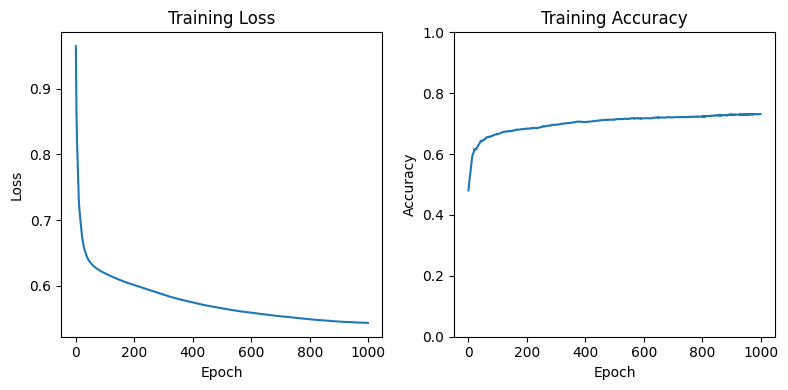

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# -------------------------
# Loss plot
# -------------------------
axes[0].plot(train_losses)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")

# -------------------------
# Accuracy plot
# -------------------------
axes[1].plot(train_accuracies)
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training Accuracy")

plt.tight_layout()
plt.show()



# Running the  Trained TCR CNN on Test Data

Now that we are done with training, lets evaluate our CNN by testing it on unseen TCR repertoire data.
Instead of using individual sequence predictions, we aggregate results to obtain **sample-level scores**.

---

## Inference Workflow

### Step 1 — Load Trained Model (if the model is saved to a path)

A pretrained CNN is used to generate predictions without further training.

---

### Step 2 — Prepare Test Data

Each file contains multiple TCR sequences.

Each sequence is:

* Encoded using AAindex features
* Converted into a fixed-shape tensor for the model

---

### Step 3 — Run Predictions

The model outputs a cancer probability for each sequence.

---

### Step 4 — Aggregate Results

For each sample, we compute:

> Mean cancer probability across all sequences

This gives one score per repertoire.

---

## Evaluation

We assess performance using:

### ROC-AUC

Measures how well the model separates cancer and control samples.

### F1 Score

Computed using a fixed threshold on sample-level scores.

### Boxplot

Visualises distribution differences between cancer and control samples.

---

## Key Idea

The model predicts at the **sequence level**, but evaluation is performed at the **sample level** by aggregating predictions.

---

In [19]:
def load_sequences(file_path):
    """
    Load amino acid sequences from a text file.

    Each line in the file is assumed to contain one sequence.
    Empty lines are ignored.

    Parameters
    ----------
    file_path : Path or str
        Path to the sequence file.

    Returns
    -------
    list of str
        List of cleaned sequences.
    """
    with open(file_path) as f:
        return [line.strip() for line in f if line.strip()]


def encode_sequences(seqs):
    """
    Convert a list of amino acid sequences into AAindex feature tensors.

    Each sequence is transformed using `aaindex_encoding`, producing a
    fixed-length numeric representation suitable for CNN input.

    Parameters
    ----------
    seqs : list of str
        Amino acid sequences.

    Returns
    -------
    np.ndarray
        Array of shape:
        (num_sequences, sequence_length, num_features)
    """
    return np.array(
        [aaindex_encoding(seq, num_features, aaidx_dict) for seq in seqs],
        dtype=np.float32,
    )


def get_mean_cancer_prob(file_path, model):
    """
    Compute the mean cancer probability for all sequences in a single sample.

    This function treats each file as one biological sample (e.g., one patient
    or repertoire). It:
    1. loads all sequences in the file
    2. encodes them into feature tensors
    3. runs the trained model on each sequence
    4. converts logits to probabilities
    5. returns the mean probability across all sequences

    This produces a *sample-level cancer score*.

    Parameters
    ----------
    file_path : Path or str
        Path to a file containing sequences for one sample.

    model : torch.nn.Module
        Trained PyTorch model.

    Returns
    -------
    float or None
        Mean cancer probability for the sample.
        Returns None if file is empty.
    """
    # Load raw amino acid sequences for this sample
    seqs = load_sequences(file_path)

    # Skip empty samples
    if len(seqs) == 0:
        return None

    # Convert sequences → numerical feature representation
    X = encode_sequences(seqs)

    # Convert to PyTorch tensor and reshape for CNN:
    # (samples, features, sequence_length) → (batch, channels, features, sequence_length)
    X = torch.tensor(X).permute(0, 2, 1).unsqueeze(1)

    model.eval()

    with torch.no_grad():
        # Forward pass through model (logits for cancer vs control)
        logits = model(X)

        # Convert logits → probabilities
        probs = torch.softmax(logits, dim=1)[:, 1]  # cancer class probability

    # Aggregate sequence-level predictions into one sample-level score
    return probs.mean().item()

#### lets read in, preprocess, and run our trained deep learning model on the test datasets

In [22]:
# LOAD DIRECTORIES (each folder = biological group)
cancer_dir = Path(
    "/content/FIMSA-training-workshop-1/data/tutorial_3/cancer_testing_data_dir"
)
control_dir = Path(
    "/content/FIMSA-training-workshop-1/data/tutorial_3/control_testing_data_dir"
)

cancer_scores = []
control_scores = []
y_true = []
y_score = []

# cancer samples (label = 1)
for file in cancer_dir.glob("*"):
    score = get_mean_cancer_prob(file, model)
    if score is not None:
        cancer_scores.append(score)
        y_true.append(1)
        y_score.append(score)

# control samples (label = 0)
for file in control_dir.glob("*"):
    score = get_mean_cancer_prob(file, model)
    if score is not None:
        control_scores.append(score)
        y_true.append(0)
        y_score.append(score)


cancer_scores = np.array(cancer_scores)
control_scores = np.array(control_scores)

y_true = np.array(y_true)
y_score = np.array(y_score)

print(f"cancer samples: {len(cancer_scores)}")
print(f"control samples: {len(control_scores)}")

cancer samples: 20
control samples: 71


Sample-level ROC-AUC: 1.0000
Sample-level F1 score: 0.9756


/tmp/ipykernel_1715/672984361.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


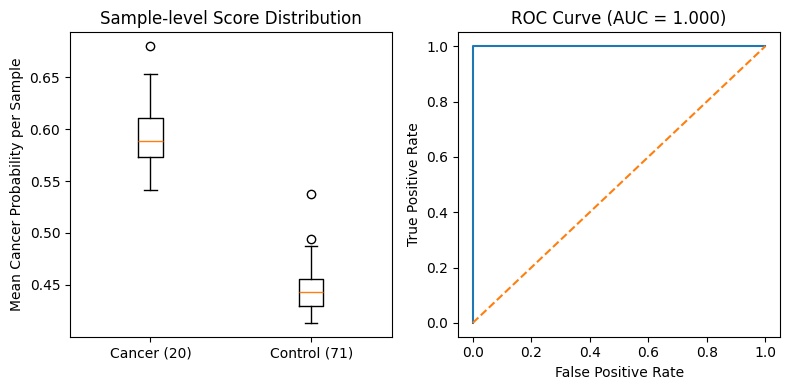

In [23]:
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

# AUC + ROC CURVE
auc = roc_auc_score(y_true, y_score)
print(f"Sample-level ROC-AUC: {auc:.4f}")

# -------------------------
# F1 SCORE (threshold = 0.5)
# -------------------------
y_pred = (np.array(y_score) >= 0.5).astype(int)
f1 = f1_score(y_true, y_pred)

print(f"Sample-level F1 score: {f1:.4f}")

fpr, tpr, _ = roc_curve(y_true, y_score)

# PLOTTING
plt.figure(figsize=(8, 4))

# --- boxplot ---
plt.subplot(1, 2, 1)
plt.boxplot(
    [cancer_scores, control_scores],
    labels=[f"Cancer ({len(cancer_scores)})", f"Control ({len(control_scores)})"],
)
plt.ylabel("Mean Cancer Probability per Sample")
plt.title("Sample-level Score Distribution")

# --- ROC curve ---
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.3f})")

plt.tight_layout()
plt.show()

# Summary

In this notebook, we explored:

* The structure of TCR sequencing datasets
* Common machine learning and deep learning libraries
* Training a small deep learning model
* Running inference with trained models
* Biological interpretation and evaluation concepts

Deep learning is becoming an increasingly important tool in computational immunology and bioinformatics, enabling researchers to uncover complex patterns in immune receptor data.